In [11]:
import numpy as np
from scipy import integrate, optimize
import matplotlib.pyplot as plt
import seaborn as sns

import astropy.units as u
import astropy.constants as const
from astropy.table import Table, QTable
from astropy.visualization import quantity_support
quantity_support()  


import sys, os
from pathlib import Path

# 设置路径为 project 的路径。按需调整
project_path = Path('~/Codes/JWST_LRD_SED/LRD_dust_modeling').expanduser()
os.chdir(project_path)

# 添加 src 目录到 sys.path
module_path = project_path / 'src'
sys.path.insert(0, str(module_path))
from LRD_IR_spectrum import *

# u.set_enabled_equivalencies(u.spectral())  # enable convenient equivalencies for converting between nu, lambda

In [2]:
# deep reload LRD_IR_spectrum
import LRD_IR_spectrum
deep_reload(LRD_IR_spectrum)
from LRD_IR_spectrum import *

## Data

### Orion Opacity, Temple SED

In [12]:
Orion_opacity = OpacityData('data/raw/Orion_Tdust20_Sigma_23_Thickness_16_Hden_07.opc')
Temple_SED = SED.from_file('data/raw/quasar5.template')
# Temple_SED = SED.from_file('data/raw/quasar5_ly.template')

### Labbe photometric data

In [7]:
Labbe_photo_raw = Table.read('data/raw/Labbe_photo.dat', format='ascii', names=['lg_lambda', 'lg_nu_L_nu'], )
Labbe_photo = QTable({'wavelength_obs': 10**Labbe_photo_raw['lg_lambda'] * u.micron, 
                      'nu_L_nu': 10**Labbe_photo_raw['lg_nu_L_nu'] * u.Lsun},
                     meta={'z': 4.4655, })
# Labbe_photo.meta = {'z': 4.4655, }
Labbe_photo['wavelength_rest'] = Labbe_photo['wavelength_obs'] / (1 + Labbe_photo.meta['z'])
Labbe_photo['nu_obs'] = Labbe_photo['wavelength_obs'].to(u.Hz, equivalencies=u.spectral())
Labbe_photo['nu_rest'] = Labbe_photo['wavelength_rest'].to(u.Hz, equivalencies=u.spectral())
Labbe_photo['Lnu_obs'] = Labbe_photo['nu_L_nu'] / Labbe_photo['nu_obs']
Labbe_photo['Lnu_rest'] = Labbe_photo['nu_L_nu'] / Labbe_photo['nu_rest']

In [ ]:
Labbe_photo

wavelength_obs,nu_L_nu,wavelength_rest,nu_obs,nu_rest,Lnu_obs,Lnu_rest
micron,solLum,micron,Hz,Hz,solLum / Hz,solLum / Hz
float64,float64,float64,float64,float64,float64,float64
0.7019960960111995,8312047745.422186,0.1284413312617692,427057158442113.56,2334080899465371.0,1.9463548569807807e-05,3.561165230959256e-06
0.899984029546824,16837490832.18056,0.16466636712959914,333108642106634.75,1820605283433812.0,5.0546544591870847e-05,9.248292853695152e-06
1.1498548924823908,18624001274.96198,0.2103842086693607,260721991931335.03,1424976046900711.5,7.143241403228802e-05,1.3069694269927365e-05
1.4043754647291624,25203441893.940323,0.2569527883504094,213470304437293.62,1166721948902028.0,0.00011806532979084111,2.1601926592414442e-05
1.4930744380738064,25203441893.940323,0.27318167378534564,200788688330072.75,1097410576068012.4,0.00012552221991962446,2.296628303350553e-05
1.6235331166307188,22406032599.149887,0.2970511603020252,184654353477034.38,1009228368928731.2,0.00012134039721915652,2.220115217622478e-05
1.846840196204909,18624001274.96198,0.33790873592624815,162327232543479.72,887199489466388.4,0.00011473121905145212,2.099189809742057e-05
1.9765326632949234,30835507096.780453,0.3616380318900235,151675944226613.2,828984873170554.2,0.00020329859988021772,3.7196706592300384e-05


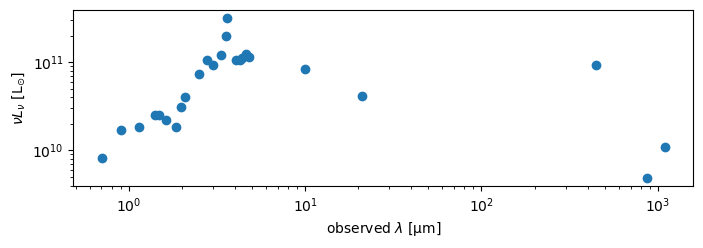

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x='wavelength_obs', y='nu_L_nu', data=Labbe_photo, )
ax.set_xlabel(fr'observed $\lambda$ [{ax.get_xlabel()}]') 
ax.set_ylabel(fr'$\nu L_\nu$ [{ax.get_ylabel()}]') 
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_aspect(.5)
# ax = plt.gca()

## Models

In [14]:
model = A_V_Model(n_0=1e3 * u.cm**-3, gamma=.5, T_sub=1500 * u.K, A_V=3 * u.mag(), opacity=Orion_opacity, observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']))
model.calc_nu_L_nu()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


<Quantity [1.15259815e+16, 1.17146265e+16, 1.19303510e+16, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00] erg / s>